# Lab 1 – Osnovna manipulacija slika i prostori boja

Perica Rajčević


In [4]:
!rm -rf clone && git clone https://github.com/pui-sum-rv/lab1 clone && cp -a clone/. .

Cloning into 'clone'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 110 (delta 34), reused 80 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 6.53 MiB | 15.68 MiB/s, done.
Resolving deltas: 100% (34/34), done.


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [6]:
# pomocna funkcija – cv2 ucitava BGR, matplotlib treba RGB
def prikazi(img, naslov=""):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(naslov)
    plt.axis("off")


## Zadatak 1 – Prikaz pojedinih kanala


(512, 512, 3)


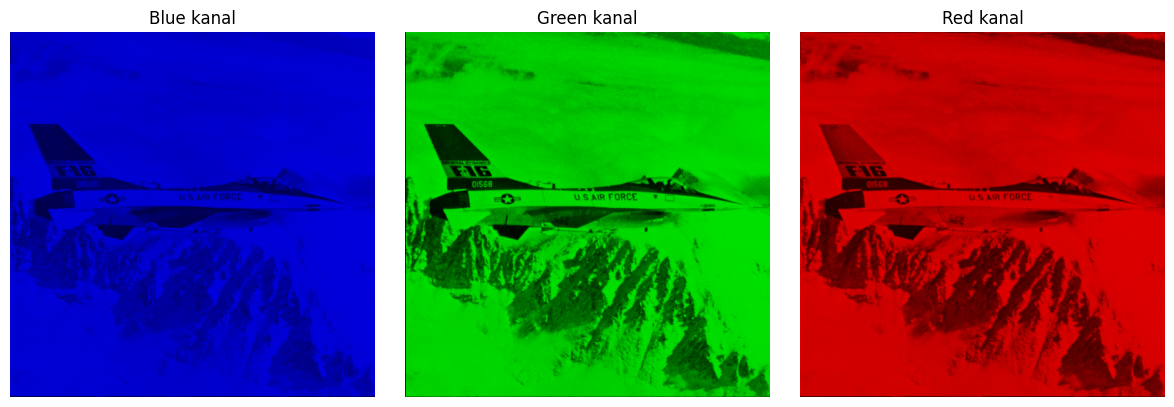

In [7]:
img = cv2.imread("images/airplane.bmp")
print(img.shape)  # provjera dimenzija

# za svaki kanal postavljam ostale na 0
# OpenCV: kanal 0 = Blue, 1 = Green, 2 = Red
b = np.zeros_like(img)
g = np.zeros_like(img)
r = np.zeros_like(img)

b[:, :, 0] = img[:, :, 0]
g[:, :, 1] = img[:, :, 1]
r[:, :, 2] = img[:, :, 2]

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
prikazi(b, "Blue kanal")
plt.subplot(1, 3, 2)
prikazi(g, "Green kanal")
plt.subplot(1, 3, 3)
prikazi(r, "Red kanal")
plt.tight_layout()
plt.show()


## Zadatak 2 – Dodavanje ruba


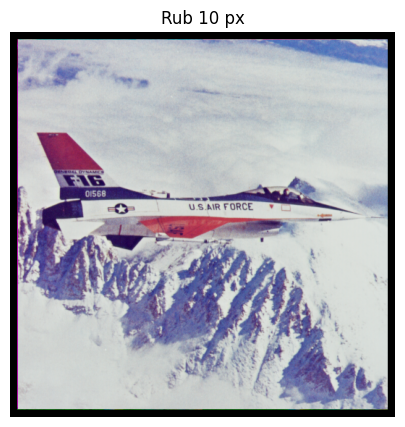

In [8]:
img = cv2.imread("images/airplane.bmp")

# dodajem rub od 10 piksela sa svih strana, crna boja
bordered = cv2.copyMakeBorder(img, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=(0, 0, 0))

plt.figure(figsize=(6, 5))
prikazi(bordered, "Rub 10 px")
plt.show()


## Zadatak 3 – Uzimanje svakog drugog piksela


Original: (512, 512, 3)
Pola redova: (256, 512, 3)
Pola stupaca: (512, 256, 3)
Pola oboje: (256, 256, 3)


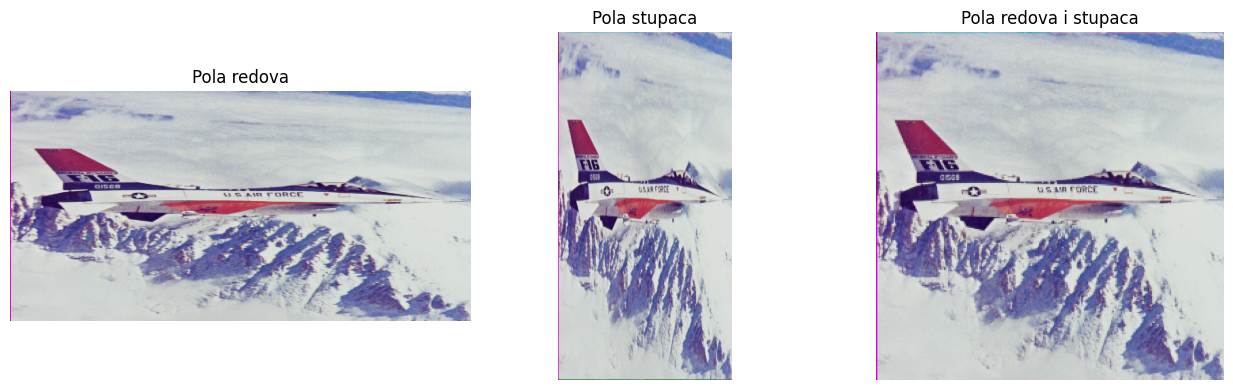

In [9]:
img = cv2.imread("images/airplane.bmp")

half_rows = img[::2, :, :]    # svaki drugi red
half_cols = img[:, ::2, :]    # svaki drugi stupac
half_both = img[::2, ::2, :]  # svaki drugi red i stupac

print("Original:", img.shape)
print("Pola redova:", half_rows.shape)
print("Pola stupaca:", half_cols.shape)
print("Pola oboje:", half_both.shape)

plt.figure(figsize=(13, 4))
plt.subplot(1, 3, 1)
prikazi(half_rows, "Pola redova")
plt.subplot(1, 3, 2)
prikazi(half_cols, "Pola stupaca")
plt.subplot(1, 3, 3)
prikazi(half_both, "Pola redova i stupaca")
plt.tight_layout()
plt.show()


## Color spaces – Zadatak 1

Ucitavam sliku, konvertujem u HSV, dodajem 30 na H kanal i prikazujem rezultat.


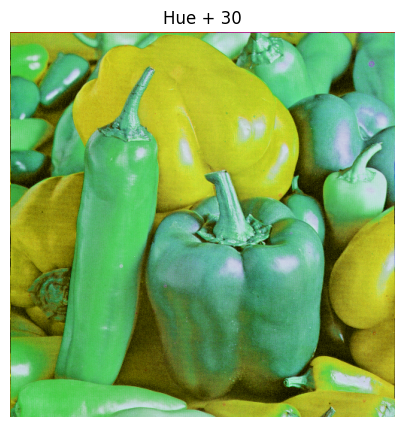

In [10]:
# u repozitoriju je pepper.bmp (task kaze peppers.png ali fajl je pepper.bmp)
img = cv2.imread("images/pepper.bmp")

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
hsv2 = hsv.copy()

# H je u rangu 0-179, koristim int16 da izbjegnem overflow pri sabiranju
hsv2[:, :, 0] = ((hsv2[:, :, 0].astype(np.int16) + 30) % 180).astype(np.uint8)

result = cv2.cvtColor(hsv2, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(result)
plt.title("Hue + 30")
plt.axis("off")
plt.show()


## Color spaces – Zadatak 2

Isti postupak ali H kanal postavljam na 0 (crvena nijansa).


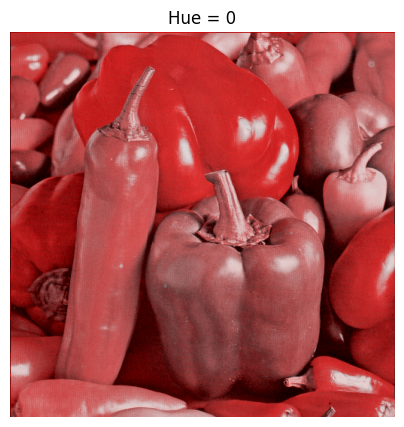

In [11]:
img = cv2.imread("images/pepper.bmp")

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
hsv2 = hsv.copy()
hsv2[:, :, 0] = 0

result = cv2.cvtColor(hsv2, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(result)
plt.title("Hue = 0")
plt.axis("off")
plt.show()
